In [1]:
#   Copyright 2022 - 2026 The PyMC Labs Developers
#
#   Licensed under the Apache License, Version 2.0 (the "License");
#   you may not use this file except in compliance with the License.
#   You may obtain a copy of the License at
#
#       http://www.apache.org/licenses/LICENSE-2.0
#
#   Unless required by applicable law or agreed to in writing, software
#   distributed under the License is distributed on an "AS IS" BASIS,
#   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#   See the License for the specific language governing permissions and
#   limitations under the License.
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.19.1
#   kernelspec:
#     display_name: .venv
#     language: python
#     name: python3
# ---

# Hierarchical Forecasting for Fresh Retail Demand with NumPyro

The [FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K)
dataset contains 50,000 daily store-product demand series from fresh retail operations. Its
native stockout indicators make it a useful public benchmark for forecasting under partial
availability, a central challenge described in the accompanying
[paper](https://arxiv.org/abs/2505.16319).

In this walkthrough we build a hierarchical NumPyro model in the style of the earlier
[hierarchical forecasting](https://juanitorduz.github.io/numpyro_hierarchical_forecasting_1/)
posts. The model combines a local-linear trend, weekly seasonality, store-level pooling for
product covariate effects, level-scaled observation noise, and an availability factor that
controls for out-of-stock periods.

In [2]:
"""Hierarchical FreshRetailNet forecasting walkthrough."""

'Hierarchical FreshRetailNet forecasting walkthrough.'

In [3]:
from collections.abc import Sequence

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
import polars as pl
import preliz as pz
import seaborn as sns
from huggingface_hub import hf_hub_download
from jax import lax, random
from jaxtyping import Array, Bool, Float, Int
from matplotlib.axes import Axes
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import LocScaleReparam

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
# %load_ext jaxtyping
# %jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Read Data

FreshRetailNet-50K contains 90 daily observations per store-product series, together with
promotion, calendar, weather, and stockout signals. We use the daily aggregate `sale_amount`
and the daytime stockout count `stock_hour6_22_cnt`; the hourly arrays are left for a future
extension.

In [4]:
local_path: str = hf_hub_download(
    repo_id="Dingdong-Inc/FreshRetailNet-50K",
    filename="data/train.parquet",
    repo_type="dataset",
)
raw_df = pl.read_parquet(local_path)

raw_df.schema


Schema([('city_id', Int64),
        ('store_id', Int64),
        ('management_group_id', Int64),
        ('first_category_id', Int64),
        ('second_category_id', Int64),
        ('third_category_id', Int64),
        ('product_id', Int64),
        ('dt', String),
        ('sale_amount', Float64),
        ('hours_sale', List(Float64)),
        ('stock_hour6_22_cnt', Int32),
        ('hours_stock_status', List(Int64)),
        ('discount', Float64),
        ('holiday_flag', Int32),
        ('activity_flag', Int32),
        ('precpt', Float64),
        ('avg_temperature', Float64),
        ('avg_humidity', Float64),
        ('avg_wind_level', Float64)])

## Exploratory Data Analysis

The columns used below cover the target, the store-product identifiers, promotion and
calendar covariates, and the stockout proxy. Weather fields are visible in the schema but are
not used as model covariates here, keeping the model focused on demand, price, promotion, and
availability.

In [5]:
schema_summary = pl.DataFrame(
    {
        "column": [
            "sale_amount",
            "hours_sale",
            "stock_hour6_22_cnt",
            "hours_stock_status",
            "discount",
            "activity_flag",
            "holiday_flag",
            "precpt / temperature / humidity / wind",
            "city_id / store_id / product_id",
        ],
        "description": [
            "Daily sales amount used as the response.",
            "Hourly sales vector, not modeled in this walkthrough.",
            "Number of daytime hours with stockout from 6:00 to 22:00.",
            "Hourly stock status vector, not modeled directly here.",
            "Observed discount multiplier; 1.0 means no discount.",
            "Binary promotion activity flag.",
            "Binary holiday flag.",
            "Weather controls left for future work.",
            "Hierarchical and series identifiers.",
        ],
    }
)
display(schema_summary)

column,description
str,str
"""sale_amount""","""Daily sales amount used as the…"
"""hours_sale""","""Hourly sales vector, not model…"
"""stock_hour6_22_cnt""","""Number of daytime hours with s…"
"""hours_stock_status""","""Hourly stock status vector, no…"
"""discount""","""Observed discount multiplier; …"
"""activity_flag""","""Binary promotion activity flag…"
"""holiday_flag""","""Binary holiday flag."""
"""precpt / temperature / humidit…","""Weather controls left for futu…"
"""city_id / store_id / product_i…","""Hierarchical and series identi…"


In [ ]:
data_df = (
    raw_df.rename({"dt": "t", "sale_amount": "y"})
    .with_columns(
        pl.col("t").cast(pl.Date),
        (
            # pl.col("stock_hour6_22_cnt")
            # .cast(pl.Float64)
            # .truediv(pl.lit(22 - 6))
            # .clip(0, 1)
            pl.col("hours_stock_status")
            .list.sum()
            .cast(pl.Float64)
            .truediv(pl.lit(24.0))
        ).alias("stockout_share"),
        pl.concat_str(["store_id", "product_id"], separator="::").alias("unique_id"),
        pl.lit(1.0).sub(pl.col("discount")).alias("discount_magnitude"),
    )
    .with_columns(pl.lit(1.0).sub(pl.col("stockout_share")).alias("availability_share"))
)

data_df.head()

city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,t,y,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,stockout_share,unique_id,discount_magnitude,availability_share
i64,i64,i64,i64,i64,i64,i64,date,f64,list[f64],i32,list[i64],f64,i32,i32,f64,f64,f64,f64,f64,str,f64,f64
0,0,0,5,6,65,38,2024-03-28,0.1,"[0.0, 0.0, … 0.0]",0,"[0, 0, … 0]",1.0,0,0,1.6999,15.48,73.54,1.97,0.0,"""0::38""",0.0,1.0
0,0,0,5,6,65,38,2024-03-29,0.1,"[0.0, 0.0, … 0.0]",1,"[0, 0, … 1]",1.0,0,0,3.019,15.08,76.56,1.71,0.125,"""0::38""",0.0,0.875
0,0,0,5,6,65,38,2024-03-30,0.0,"[0.0, 0.0, … 0.0]",0,"[1, 1, … 0]",1.0,1,0,2.0942,15.91,76.47,1.73,0.25,"""0::38""",0.0,0.75
0,0,0,5,6,65,38,2024-03-31,0.1,"[0.0, 0.0, … 0.0]",11,"[0, 0, … 1]",1.0,1,0,1.5618,16.13,77.4,1.76,0.541667,"""0::38""",0.0,0.458333
0,0,0,5,6,65,38,2024-04-01,0.2,"[0.0, 0.0, … 0.0]",8,"[1, 1, … 1]",1.0,0,0,3.5386,15.37,78.26,1.25,0.625,"""0::38""",0.0,0.375


In [7]:
count_summary = data_df.select(
    pl.col("city_id").n_unique().alias("n_cities"),
    pl.col("store_id").n_unique().alias("n_stores"),
    pl.col("product_id").n_unique().alias("n_products"),
    pl.concat_str(["store_id", "product_id"], separator="::")
    .n_unique()
    .alias("n_store_products"),
)

count_summary

n_cities,n_stores,n_products,n_store_products
u32,u32,u32,u32
18,898,865,50000


<Axes: xlabel='stockout_share', ylabel='len'>

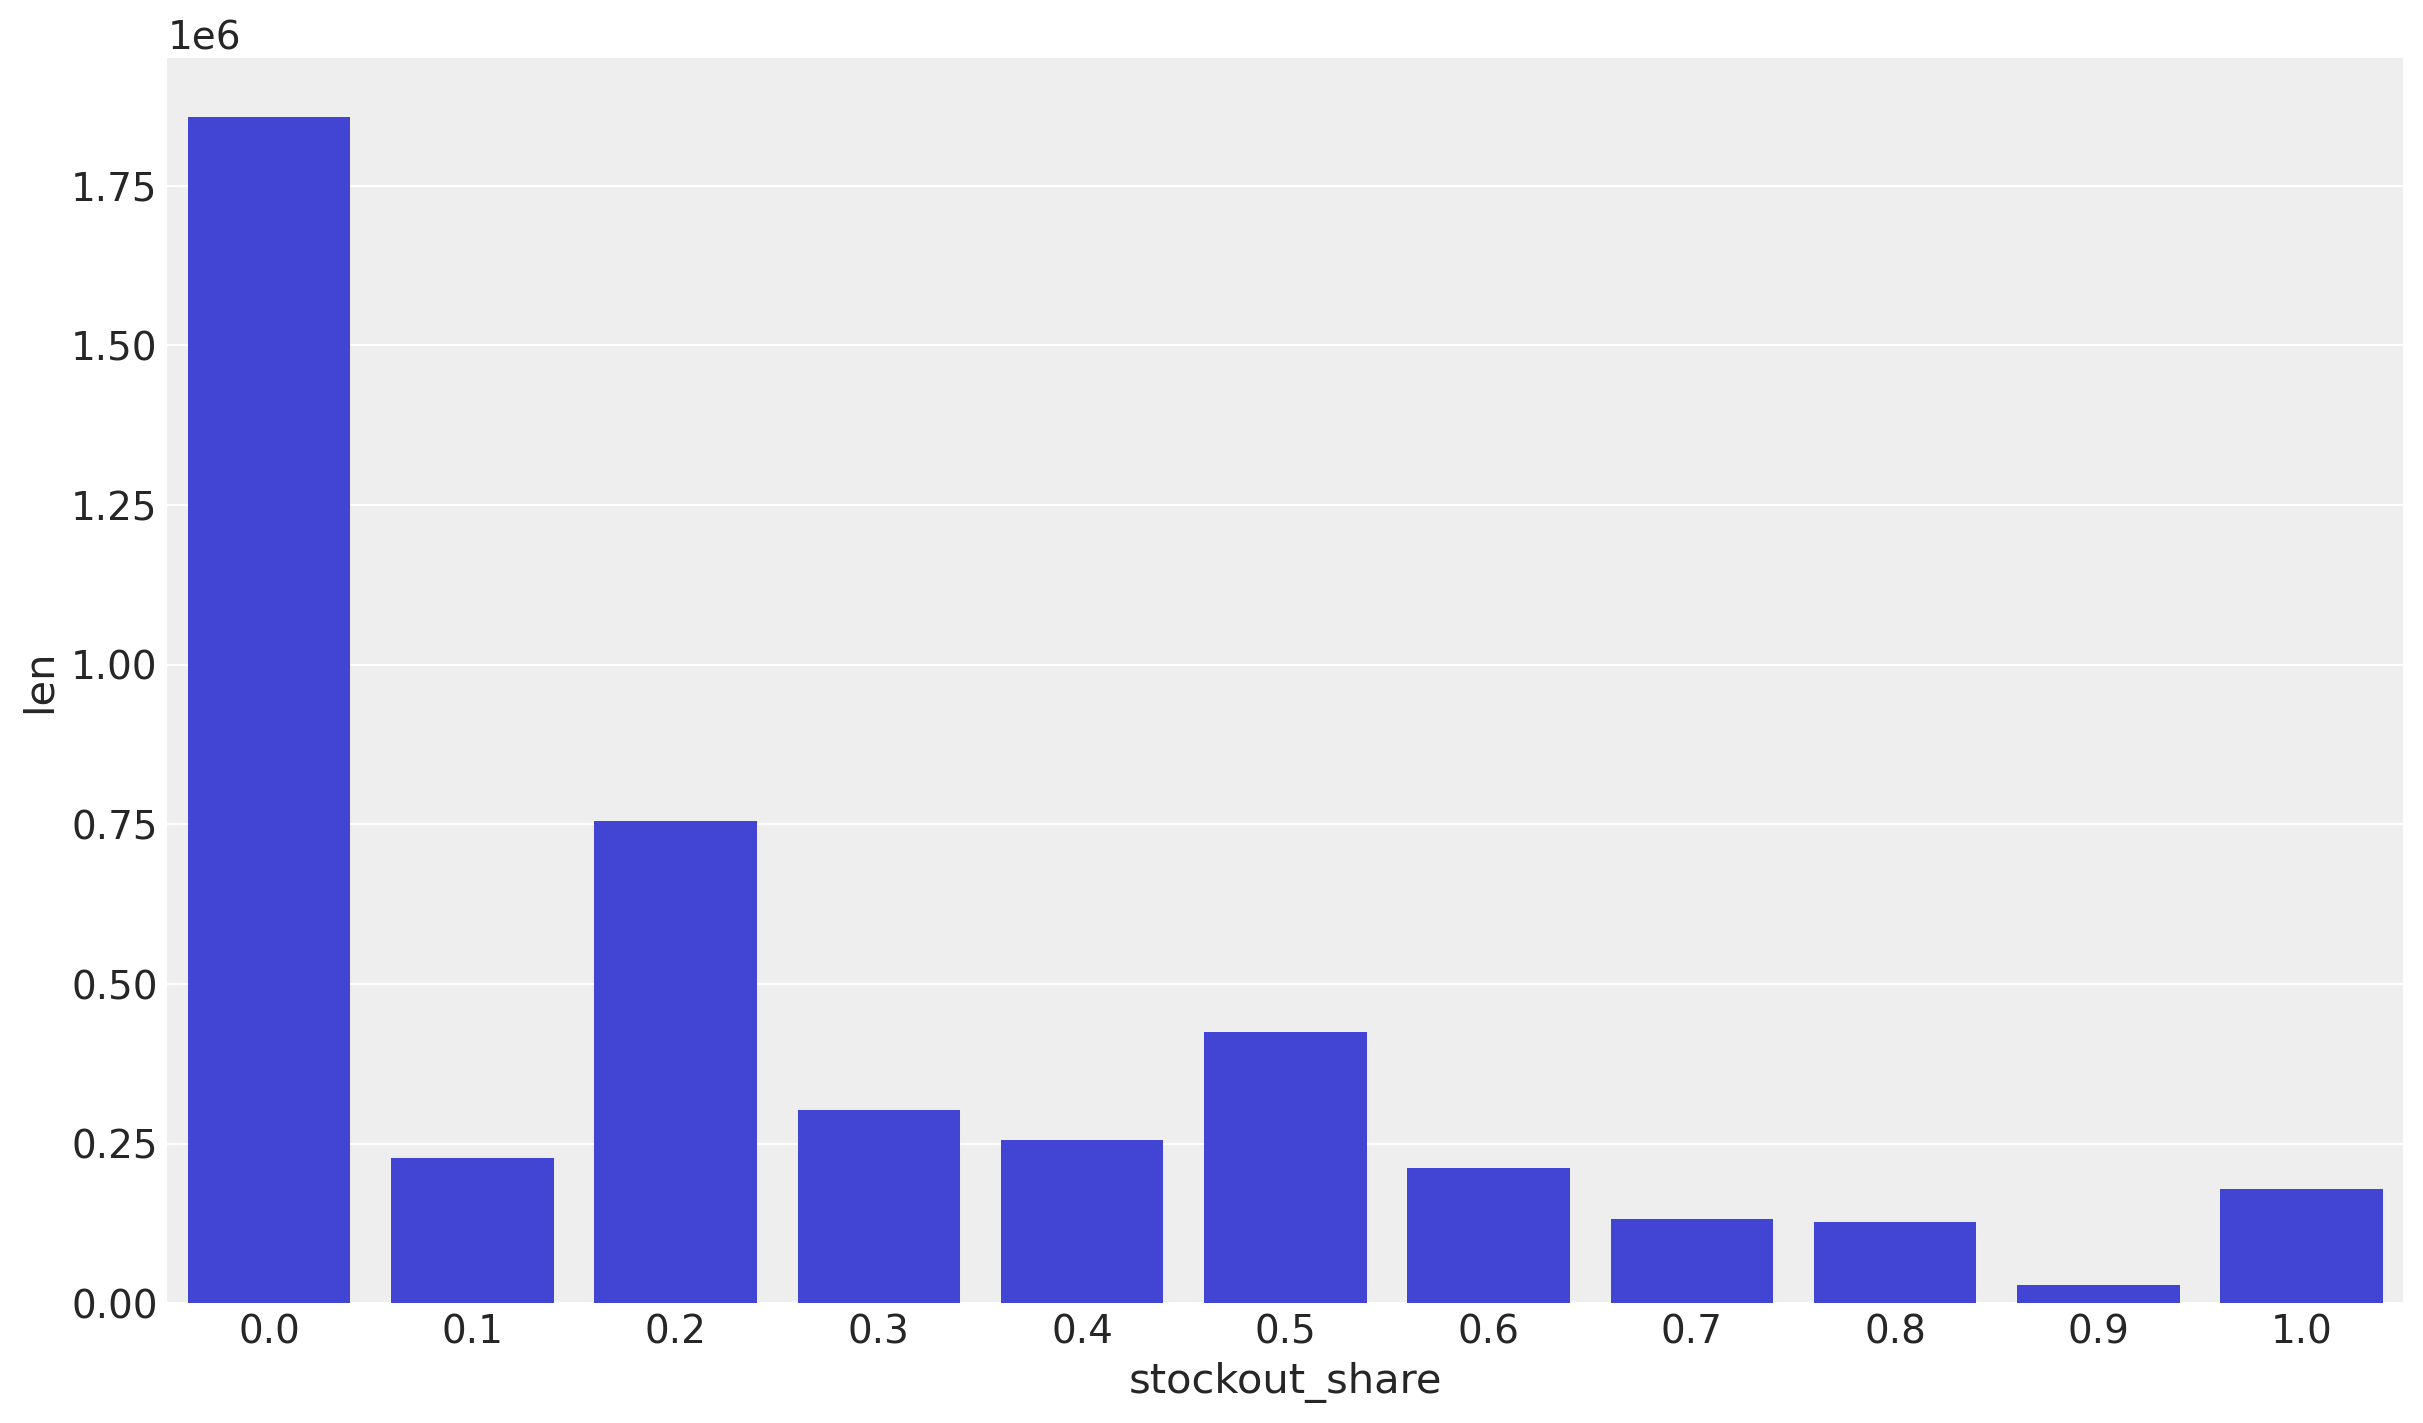

In [8]:
(
    data_df.with_columns(pl.col("stockout_share").round(1))
    .group_by("stockout_share")
    .len()
    .sort("stockout_share")
    .pipe(sns.barplot, x="stockout_share", y="len")
)

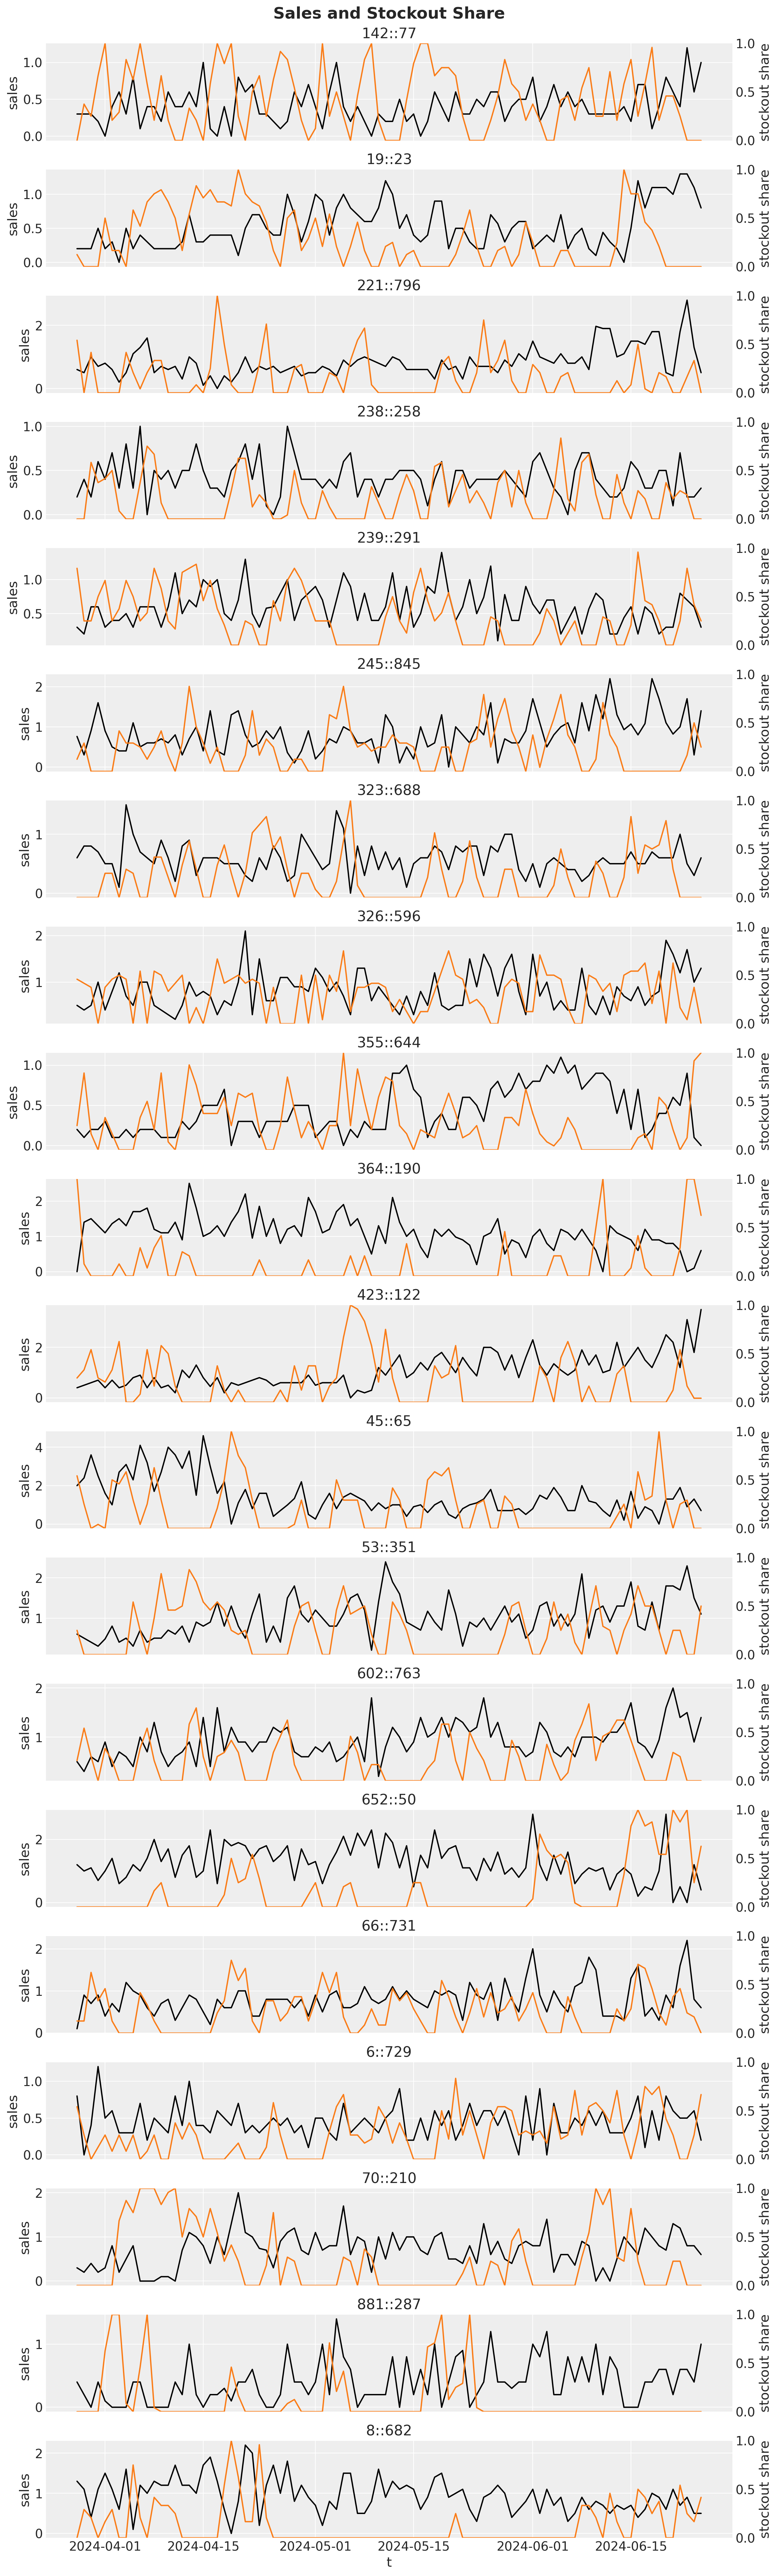

In [9]:
n_series_to_to_plot = 20


sample_series_ids: list[str] = (
    data_df.select("unique_id")
    .unique()
    .sample(n=n_series_to_to_plot, seed=42)
    .sort("unique_id")["unique_id"]
    .to_list()
)

sample_series_df = data_df.with_columns().filter(
    pl.col("unique_id").is_in(sample_series_ids)
)

fig, axes = plt.subplots(
    nrows=len(sample_series_ids),
    figsize=(12, 2 * len(sample_series_ids)),
    sharex=True,
    sharey=False,
    layout="constrained",
)

for ax, unique_id in zip(axes, sample_series_ids, strict=True):
    condition = pl.col("unique_id").eq(pl.lit(unique_id))
    plot_df = sample_series_df.filter(condition).sort("t")
    sns.lineplot(
        data=plot_df,
        x="t",
        y="y",
        color="black",
        ax=ax,
    )
    ax.set(title=unique_id, ylabel="sales")

    ax_twin = ax.twinx()
    sns.lineplot(
        data=plot_df,
        x="t",
        y="stockout_share",
        color="C1",
        ax=ax_twin,
    )
    ax_twin.grid(None)
    ax_twin.set(ylabel="stockout share", ylim=(0, 1))

fig.suptitle("Sales and Stockout Share", fontsize=18, fontweight="bold");

In [15]:
data_df.filter(
    pl.col("availability_share").eq(pl.lit(0.0)) & pl.col("y").gt(pl.lit(0.0))
).shape[0] / data_df.shape[0]

0.005599111111111111

In [17]:
data_df.filter(
    pl.col("availability_share").eq(pl.lit(0.0)) & pl.col("y").gt(pl.lit(0.0))
).shape[0] / data_df.filter(pl.col("availability_share").eq(pl.lit(0.0))).shape[0]

0.14758928519128148

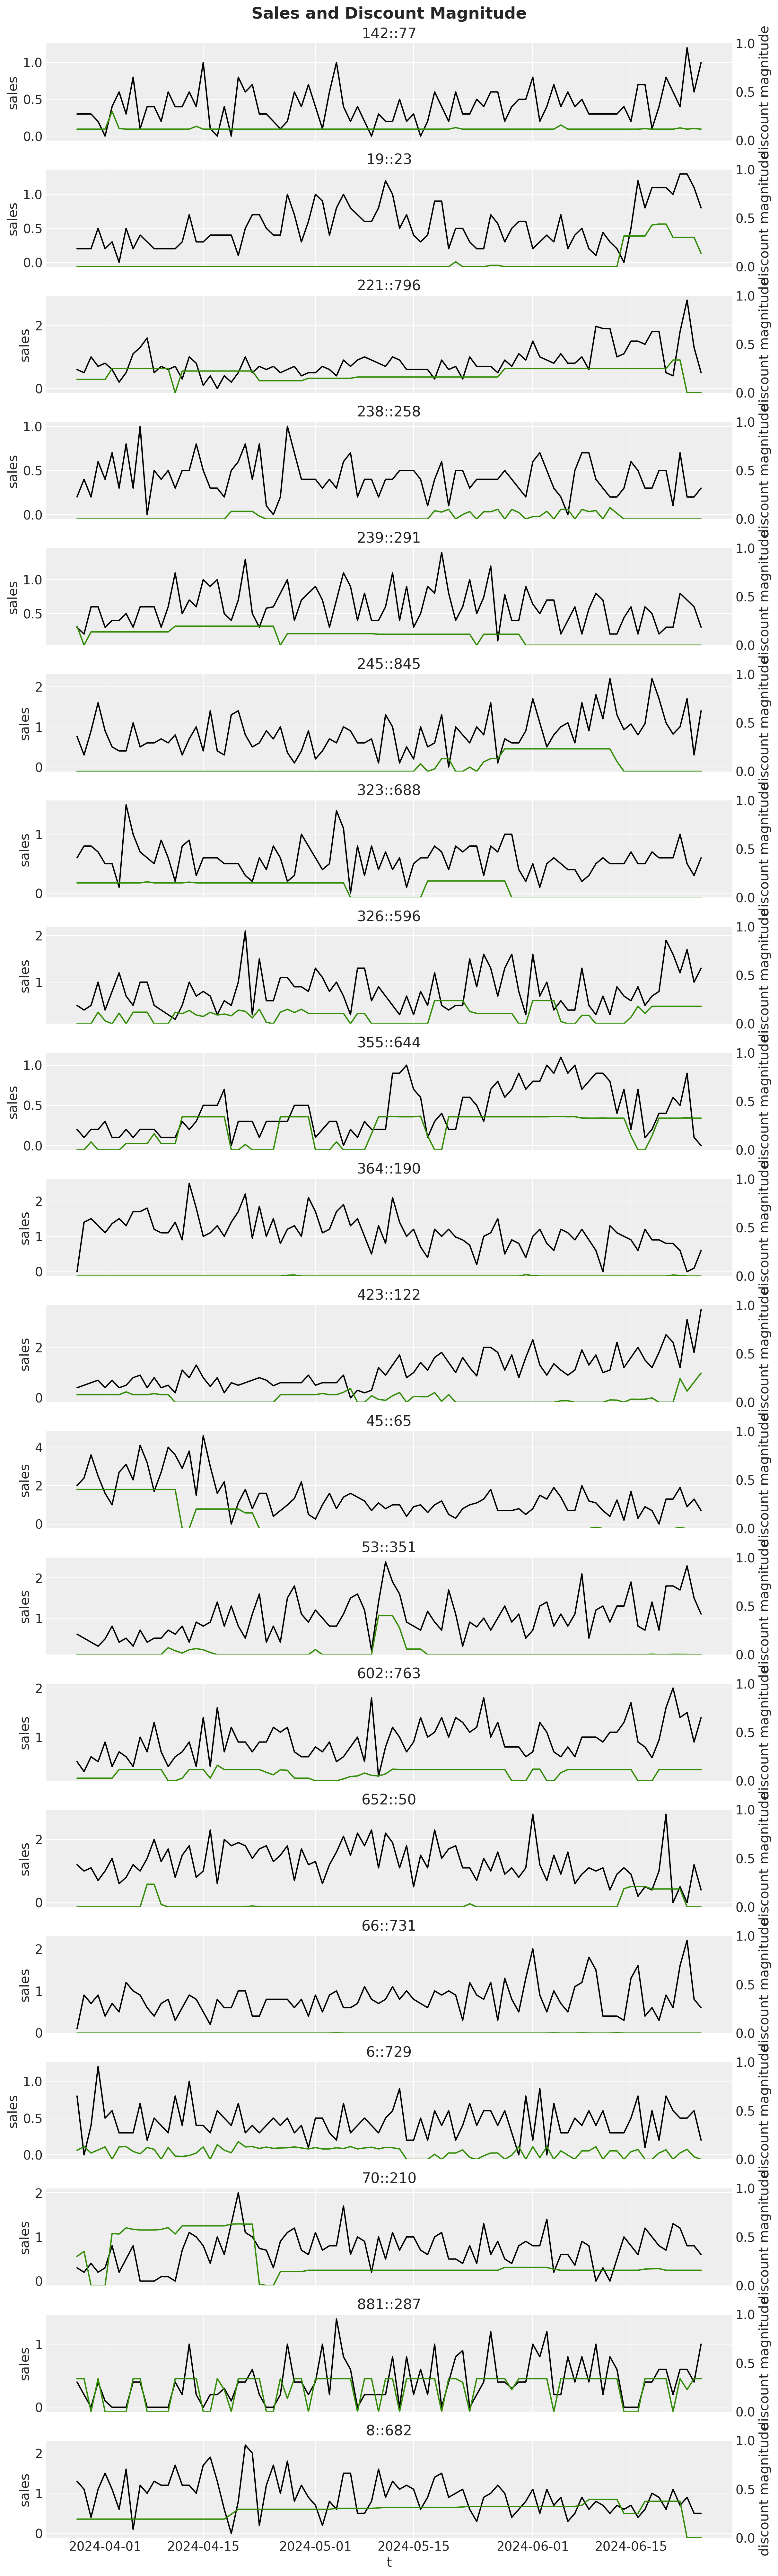

In [11]:
fig, axes = plt.subplots(
    nrows=len(sample_series_ids),
    figsize=(12, 2 * len(sample_series_ids)),
    sharex=True,
    sharey=False,
    layout="constrained",
)

for ax, unique_id in zip(axes, sample_series_ids, strict=True):
    condition = pl.col("unique_id").eq(pl.lit(unique_id))
    plot_df = sample_series_df.filter(condition).sort("t")
    sns.lineplot(
        data=plot_df,
        x="t",
        y="y",
        color="black",
        ax=ax,
    )
    ax.set(title=unique_id, ylabel="sales")

    ax_twin = ax.twinx()
    sns.lineplot(
        data=plot_df,
        x="t",
        y="discount_magnitude",
        color="C2",
        ax=ax_twin,
    )
    ax_twin.grid(None)
    ax_twin.set(ylabel="discount magnitude", ylim=(0, 1))

fig.suptitle("Sales and Discount Magnitude", fontsize=18, fontweight="bold");

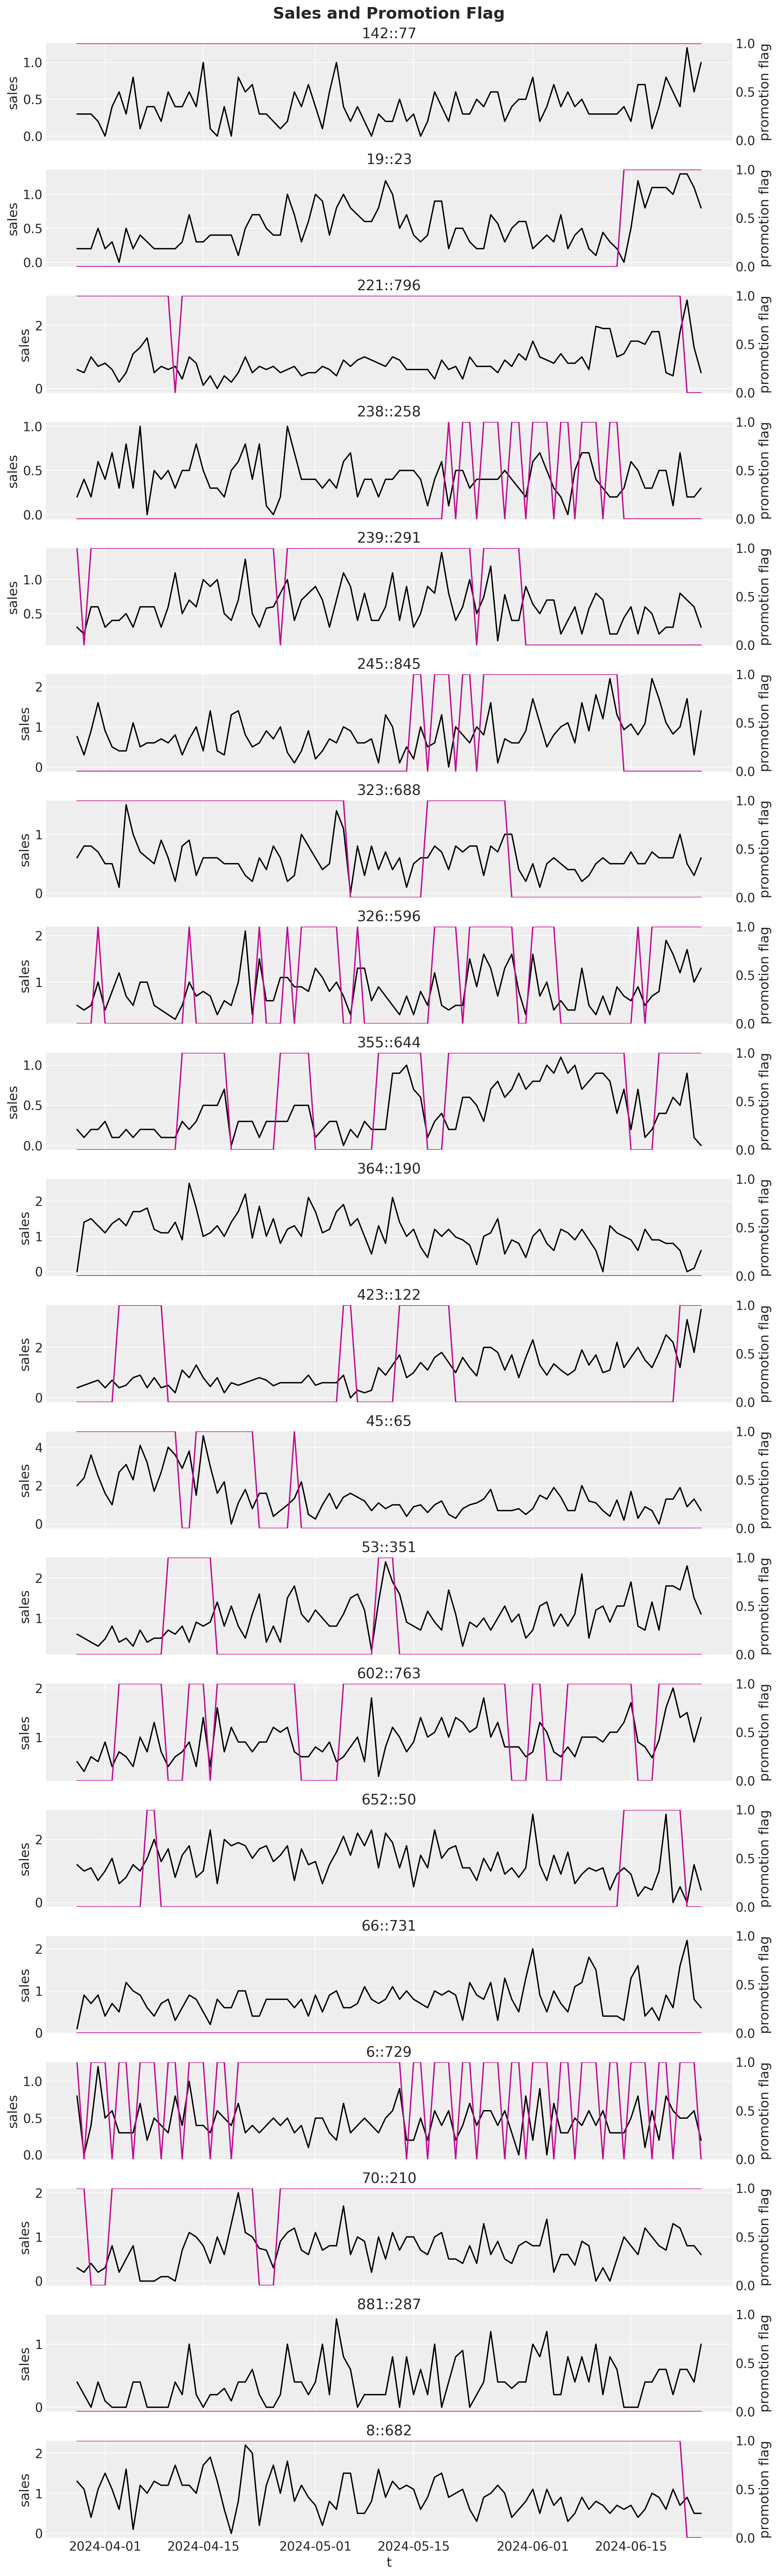

In [12]:
fig, axes = plt.subplots(
    nrows=len(sample_series_ids),
    figsize=(12, 2 * len(sample_series_ids)),
    sharex=True,
    sharey=False,
    layout="constrained",
)

for ax, unique_id in zip(axes, sample_series_ids, strict=True):
    condition = pl.col("unique_id").eq(pl.lit(unique_id))
    plot_df = sample_series_df.filter(condition).sort("t")
    sns.lineplot(
        data=plot_df,
        x="t",
        y="y",
        color="black",
        ax=ax,
    )
    ax.set(title=unique_id, ylabel="sales")

    ax_twin = ax.twinx()
    sns.lineplot(
        data=plot_df,
        x="t",
        y="activity_flag",
        color="C3",
        ax=ax_twin,
    )
    ax_twin.grid(None)
    ax_twin.set(ylabel="promotion flag", ylim=(0, 1))

fig.suptitle("Sales and Promotion Flag", fontsize=18, fontweight="bold");

## Pre-Process Data

The response is scaled by each series' mean sale amount, which helps the shared priors work
across products with very different volumes. Availability is derived from the daytime stockout
count and clipped away from zero so the multiplicative availability factor remains stable.

In [13]:
eps = np.finfo("float32").eps

prepared_df = (
    raw_df.with_columns(
        pl.concat_str(["store_id", "product_id"], separator="::").alias("unique_id"),
        (1 - pl.col("stock_hour6_22_cnt") / 17)
        .clip(eps, 1)
        .alias("availability_share"),
    )
    .with_columns(pl.col("sale_amount").mean().over("unique_id").alias("y_factor"))
    .with_columns(
        (pl.col("sale_amount") / (pl.col("y_factor") + eps)).alias("y_scaled")
    )
    .rename({"dt": "ds", "sale_amount": "y"})
)

display(
    prepared_df.select(
        "ds", "unique_id", "store_id", "product_id", "y", "y_factor", "y_scaled"
    ).head()
)

ds,unique_id,store_id,product_id,y,y_factor,y_scaled
str,str,i64,i64,f64,f64,f64
"""2024-03-28""","""0::38""",0,38,0.1,0.436667,0.229008
"""2024-03-29""","""0::38""",0,38,0.1,0.436667,0.229008
"""2024-03-30""","""0::38""",0,38,0.0,0.436667,0.0
"""2024-03-31""","""0::38""",0,38,0.1,0.436667,0.229008
"""2024-04-01""","""0::38""",0,38,0.2,0.436667,0.458015


## Format Data

We keep the top 1,000 store-product series by total sales and reserve the last 14 days as a
holdout window. The model still receives full-length covariate arrays; during SVI we mask the
holdout observations, which keeps the guide shape fixed for posterior forecasting.

In [ ]:
n_series_to_use = 5_000
forecasting_horizon = 14

top_series_df = (
    prepared_df.group_by("unique_id")
    .agg(pl.col("y").sum().alias("total_sales"))
    .sort("total_sales", descending=True)
    .head(n_series_to_use)
)

selected_df = prepared_df.join(
    top_series_df.select("unique_id"), on="unique_id", how="inner"
)
series_ids = (
    selected_df.select("unique_id").unique().sort("unique_id")["unique_id"].to_list()
)
n_series = len(series_ids)

start_date = selected_df.select(pl.col("ds").min()).item()
end_date = selected_df.select(pl.col("ds").max()).item()
full_date_df = pl.DataFrame(
    {"ds": pl.date_range(start=start_date, end=end_date, interval="1d", eager=True)}
)
time = full_date_df["ds"].to_numpy()
t_max = len(time)
t_max_train = t_max - forecasting_horizon
time_train = time[:t_max_train]

if t_max_train <= 7:
    raise ValueError(
        "The training window must contain more than one weekly seasonal cycle."
    )

In [ ]:
def make_pivot(df: pl.DataFrame, value: str, fill_value: float) -> pl.DataFrame:
    """Create a dense date-by-series pivot with columns sorted by series id."""
    pivot_df = df.pivot(
        index="ds", on="unique_id", values=value, aggregate_function="first"
    )
    missing_series = [
        series_id for series_id in series_ids if series_id not in pivot_df.columns
    ]
    if missing_series:
        raise ValueError(
            f"Missing selected series in pivot for {value}: {missing_series[:5]}"
        )
    return (
        full_date_df.join(pivot_df, on="ds", how="left")
        .select(["ds", *series_ids])
        .fill_null(fill_value)
    )


y_pivot_df = make_pivot(selected_df, value="y_scaled", fill_value=0.0)
availability_pivot_df = make_pivot(
    selected_df, value="availability_share", fill_value=1.0
)
discount_pivot_df = make_pivot(selected_df, value="discount", fill_value=1.0)
activity_pivot_df = make_pivot(selected_df, value="activity_flag", fill_value=0.0)
holiday_pivot_df = make_pivot(selected_df, value="holiday_flag", fill_value=0.0)

y_factor_values_df = (
    selected_df.select(["unique_id", "y_factor"]).unique().sort("unique_id")
)

store_index_df = (
    selected_df.select("store_id")
    .unique()
    .sort("store_id")
    .with_row_index(name="store_idx")
)
series_store_df = (
    selected_df.select(["unique_id", "store_id"])
    .unique()
    .join(store_index_df, on="store_id", how="left")
    .sort("unique_id")
)

n_stores = store_index_df.height
series_to_store_idx_np = series_store_df["store_idx"].to_numpy().astype(np.int32)

expected_shape = (t_max, n_series + 1)
for name, pivot_df in {
    "y": y_pivot_df,
    "availability": availability_pivot_df,
    "discount": discount_pivot_df,
    "activity": activity_pivot_df,
    "holiday": holiday_pivot_df,
}.items():
    if pivot_df.shape != expected_shape:
        raise ValueError(
            f"Unexpected {name} pivot shape: {pivot_df.shape} != {expected_shape}"
        )

if y_factor_values_df.height != n_series:
    raise ValueError("Expected one y_factor per selected series.")

display(
    pl.DataFrame(
        {
            "n_series": [n_series],
            "n_stores": [n_stores],
            "t_max": [t_max],
            "t_max_train": [t_max_train],
            "forecasting_horizon": [forecasting_horizon],
        }
    )
)

## Features

Discount is encoded as `discount_magnitude = 1 - discount`, so no discount maps to zero and
a deeper discount has a larger positive value. With this sign convention, a positive
coefficient means "more discount, more sales."

In [ ]:
y_values_np = y_pivot_df.select(series_ids).to_numpy().astype(np.float32)
availability_values_np = (
    availability_pivot_df.select(series_ids).to_numpy().astype(np.float32)
)
discount_magnitude_np = (1 - discount_pivot_df.select(series_ids).to_numpy()).astype(
    np.float32
)
activity_values_np = activity_pivot_df.select(series_ids).to_numpy().astype(np.float32)
holiday_values_np = holiday_pivot_df.select(series_ids).to_numpy().astype(np.float32)

covariates_np = np.stack(
    [discount_magnitude_np, activity_values_np, holiday_values_np],
    axis=-1,
).astype(np.float32)
covariate_names = ["discount_magnitude", "activity_flag", "holiday_flag"]
n_covariates = len(covariate_names)

y_factor_values = y_factor_values_df["y_factor"].to_numpy().astype(np.float32)
raw_y_values_np = y_values_np * y_factor_values[None, :]

y_jax = jnp.asarray(y_values_np)
availability_share_jax = jnp.asarray(availability_values_np)
covariates_jax = jnp.asarray(covariates_np)
series_to_store_idx = jnp.asarray(series_to_store_idx_np)
obs_mask = jnp.broadcast_to(jnp.arange(t_max)[:, None] < t_max_train, y_jax.shape)

In [ ]:
def periodic_repeat_jax(
    array: Float[Array, "... period"],
    size: int,
    dim: int,
) -> Float[Array, "... size"]:
    """Repeat a periodic array along one dimension.

    Adapted from ``pyro.ops.tensor_utils.periodic_repeat`` for JAX arrays.
    """
    period = array.shape[dim]
    repeats = int(np.ceil(size / period))
    repeated = jnp.concatenate([array] * repeats, axis=dim)
    return lax.slice_in_dim(repeated, start_index=0, limit_index=size, axis=dim)


seasonal_test = periodic_repeat_jax(jnp.arange(7), size=t_max, dim=0)
if seasonal_test.shape != (t_max,):
    raise ValueError(f"Unexpected periodic repeat shape: {seasonal_test.shape}")

## Model Specification

The latent trend follows a local-linear state equation:

`level_t = level_{t-1} + beta_{t-1} + drift_t`

`beta_t = beta_{t-1} + drift_beta_t`

Weekly seasonality is zero-sum within each series. The additive covariate effects are
hierarchically pooled by store: each store has covariate-specific location and scale
parameters, and each store-product coefficient is drawn from the corresponding store-level
distribution. Availability stays non-hierarchical and enters multiplicatively through
`tanh(b_availability * availability_share)`. Observation noise scales with the latent level.

In [ ]:
fig, ax = plt.subplots()
pz.LogNormal(mu=-20, sigma=5).plot_pdf(ax=ax, support=(0, 5e-5))
pz.LogNormal(mu=-25, sigma=5).plot_pdf(ax=ax, support=(0, 5e-5))
ax.set(title="Drift Priors", xlabel="Scale")
ax.legend()
plt.show()

In [ ]:
def model(
    availability_share: Float[Array, "t_max n_series"],
    covariates: Float[Array, "t_max n_series n_covariates"],
    series_to_store_idx: Int[Array, "n_series"],
    n_stores: int,
    y_init: Float[Array, "t_max n_series"] | None = None,
    y: Float[Array, "t_max n_series"] | None = None,
    obs_mask: Bool[Array, "t_max n_series"] | None = None,
) -> None:
    """FreshRetailNet hierarchical local-linear trend model."""
    eps_jax = jnp.finfo(jnp.float32).eps
    t_max_model, n_series_model, n_covariates_model = covariates.shape

    centered_drift = numpyro.sample("centered_drift", dist.Uniform(0, 1))
    centered_drift_beta = numpyro.sample("centered_drift_beta", dist.Uniform(0, 1))
    centered_b_cov = numpyro.sample("centered_b_cov", dist.Uniform(0, 1))

    with numpyro.plate("n_stores", n_stores, dim=-1):
        with numpyro.plate("n_covariates_store", n_covariates_model, dim=-2):
            b_covariate_loc_store = numpyro.sample(
                "b_covariate_loc_store", dist.Normal(0, 1)
            )
            b_covariate_scale_store = numpyro.sample(
                "b_covariate_scale_store", dist.HalfNormal(0.5)
            )

    with numpyro.plate("n_series", n_series_model, dim=-1):
        drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-20, 5))
        drift_beta_scale = numpyro.sample("drift_beta_scale", dist.LogNormal(-25, 5))
        seasonal = numpyro.sample(
            "seasonal", dist.ZeroSumNormal(scale=2, event_shape=(7,))
        )
        b_availability = numpyro.sample("b_availability", dist.LogNormal(0, 0.15))

        with numpyro.plate("n_covariates", n_covariates_model, dim=-2):
            with numpyro.handlers.reparam(
                config={"b_covariate": LocScaleReparam(centered=centered_b_cov)}
            ):
                b_covariate = numpyro.sample(
                    "b_covariate",
                    dist.Normal(
                        b_covariate_loc_store[:, series_to_store_idx],
                        b_covariate_scale_store[:, series_to_store_idx],
                    ),
                )

        sigma_global = numpyro.sample("sigma_global", dist.HalfNormal(2))
        pow_sigma = numpyro.sample("pow_sigma", dist.Uniform(eps_jax, 0.2))
        offset_sigma = numpyro.sample("offset_sigma", dist.HalfNormal(10))

        with numpyro.plate("time", t_max_model, dim=-2):
            with numpyro.handlers.reparam(
                config={
                    "drift": LocScaleReparam(centered=centered_drift),
                    "drift_beta": LocScaleReparam(centered=centered_drift_beta),
                }
            ):
                drift = numpyro.sample("drift", dist.Normal(0, drift_scale))
                drift_beta = numpyro.sample(
                    "drift_beta", dist.Normal(0, drift_beta_scale)
                )

    seasonal_repeat = periodic_repeat_jax(seasonal, t_max_model, -1).transpose()

    def transition_fn(
        carry: tuple[Float[Array, " n_series"], Float[Array, " n_series"]],
        t: Int[Array, ""],
    ) -> tuple[
        tuple[Float[Array, " n_series"], Float[Array, " n_series"]],
        Float[Array, " n_series"],
    ]:
        previous_level, previous_beta = carry
        current_level = previous_level + previous_beta + drift[t]
        current_beta = previous_beta + drift_beta[t]
        return (current_level, current_beta), current_level

    if y_init is None:
        init = jnp.ones(n_series_model)
    else:
        init = y_init[:7].mean(axis=0)

    _, pred_levels = lax.scan(
        transition_fn,
        init=(init, jnp.zeros_like(init)),
        xs=jnp.arange(t_max_model),
    )
    pred_levels_clipped = jnp.clip(pred_levels, eps_jax)

    availability_factor = jnp.tanh(b_availability * availability_share) + eps_jax
    covariates_contribution = (covariates * b_covariate.T).sum(axis=-1)
    mu = availability_factor * (pred_levels + seasonal_repeat + covariates_contribution)
    sigma = sigma_global * jnp.power(pred_levels_clipped, pow_sigma) + offset_sigma

    numpyro.deterministic("mu", mu)

    if obs_mask is None:
        obs_mask = True

    with numpyro.plate("obs_series", n_series_model, dim=-1):
        with numpyro.plate("obs_time", t_max_model, dim=-2):
            with numpyro.handlers.mask(mask=obs_mask):
                numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)

In [ ]:
numpyro.render_model(
    model,
    model_args=(
        availability_share_jax,
        covariates_jax,
        series_to_store_idx,
        n_stores,
        y_jax,
        y_jax,
        obs_mask,
    ),
    render_distributions=True,
)

## Prior Predictive Checks

Before fitting, the prior predictive distribution should be wide but still live on a plausible
scale after the per-series normalization.

In [ ]:
rng_key, rng_subkey = random.split(rng_key)
prior_predictive = Predictive(model, num_samples=200, return_sites=["obs"])(
    rng_subkey,
    availability_share_jax,
    covariates_jax,
    series_to_store_idx,
    n_stores,
    y_jax,
    None,
    None,
)

idata_prior = az.from_dict(
    prior_predictive={"obs": np.asarray(prior_predictive["obs"])[None, ...]},
    coords={"time": time, "series": series_ids},
    dims={"obs": ["time", "series"]},
)
display(idata_prior)

In [ ]:
def plot_prior_predictive_grid(
    axes: Sequence[Axes],
    series_idx: np.ndarray,
    prior_samples: np.ndarray,
    observed: np.ndarray,
    availability: np.ndarray,
    title_prefix: str,
) -> None:
    """Plot prior predictive HDI bands for a selected set of series."""
    for ax, idx in zip(axes, series_idx, strict=True):
        for j, hdi_prob in enumerate((0.94, 0.5)):
            az.plot_hdi(
                x=time_train,
                y=prior_samples[:, :t_max_train, idx],
                hdi_prob=hdi_prob,
                ax=ax,
                smooth=False,
                fill_kwargs={"alpha": 0.3 + 0.2 * j, "color": "C0"},
            )
        ax.plot(
            time_train,
            observed[:t_max_train, idx],
            color="black",
            linewidth=1,
            label="Observed",
        )
        ax.set(title=f"{title_prefix}: {series_ids[idx]}", ylabel="scaled sales")

        ax_availability = ax.twinx()
        ax_availability.plot(
            time_train, availability[:t_max_train, idx], color="C3", alpha=0.6
        )
        ax_availability.set(ylabel="availability", ylim=(0, 1.05))


n_series_to_plot = 10
rng_np = np.random.default_rng(seed=42)
random_series_idx = np.sort(
    rng_np.choice(n_series, size=n_series_to_plot, replace=False)
)

fig, axes = plt.subplots(
    nrows=n_series_to_plot,
    figsize=(15, 2 * n_series_to_plot),
    sharex=True,
    layout="constrained",
)
plot_prior_predictive_grid(
    axes=axes,
    series_idx=random_series_idx,
    prior_samples=np.asarray(prior_predictive["obs"]),
    observed=y_values_np,
    availability=availability_values_np,
    title_prefix="Prior predictive",
)
plt.show()

## Inference - SVI

We use SVI with an `AutoNormal` guide because the selected panel has 1,000 series and many
time-indexed latent states. The optimizer follows the one-cycle Adam plus
`reduce_on_plateau` recipe used in the third hierarchical forecasting post.

In [ ]:
guide = AutoNormal(model)

num_steps = 10_000
scheduler = optax.linear_onecycle_schedule(
    transition_steps=num_steps,
    peak_value=0.002,
    pct_start=0.3,
    pct_final=0.85,
    div_factor=2,
    final_div_factor=3,
)
optimizer = optax.chain(
    optax.adam(learning_rate=scheduler),
    optax.contrib.reduce_on_plateau(
        factor=0.8,
        patience=20,
        accumulation_size=100,
    ),
)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO(num_particles=2))

rng_key, rng_subkey = random.split(rng_key)
svi_result = svi.run(
    rng_subkey,
    num_steps,
    availability_share_jax,
    covariates_jax,
    series_to_store_idx,
    n_stores,
    y_jax,
    y_jax,
    obs_mask,
)

In [ ]:
fig, ax = plt.subplots()
ax.plot(np.asarray(svi_result.losses))
ax.set(yscale="log", title="SVI ELBO Loss", xlabel="Step", ylabel="Loss")
plt.show()

## Posterior Predictive Checks

The posterior predictive is generated for the full 90-day window. The final 14 days were
masked during SVI, so they behave as a true holdout forecast while retaining the actual
known covariates.

In [ ]:
rng_key, rng_subkey = random.split(rng_key)
posterior_predictive = Predictive(
    model,
    guide=guide,
    params=svi_result.params,
    num_samples=200,
    return_sites=["obs", "mu"],
)(
    rng_subkey,
    availability_share_jax,
    covariates_jax,
    series_to_store_idx,
    n_stores,
    y_jax,
    None,
    None,
)

idata = az.from_dict(
    posterior_predictive={"obs": np.asarray(posterior_predictive["obs"])[None, ...]},
    coords={"time": time, "series": series_ids},
    dims={"obs": ["time", "series"]},
)
display(idata)

In [ ]:
def plot_posterior_predictive_grid(
    axes: Sequence[Axes],
    series_idx: np.ndarray,
    posterior_samples: np.ndarray,
    observed: np.ndarray,
    availability: np.ndarray,
    title_prefix: str,
) -> None:
    """Plot train and holdout posterior predictive intervals for selected series."""
    max_train_date = time[t_max_train - 1]
    for ax, idx in zip(axes, series_idx, strict=True):
        y_scale = y_factor_values[idx]
        samples_original = posterior_samples[:, :, idx] * y_scale
        observed_original = observed[:, idx] * y_scale

        for time_slice, color, label in [
            (slice(0, t_max_train), "C0", "Train"),
            (slice(t_max_train, t_max), "C1", "Forecast"),
        ]:
            for j, hdi_prob in enumerate((0.94, 0.5)):
                az.plot_hdi(
                    x=time[time_slice],
                    y=samples_original[:, time_slice],
                    hdi_prob=hdi_prob,
                    ax=ax,
                    smooth=False,
                    fill_kwargs={"alpha": 0.3 + 0.2 * j, "color": color},
                )
            ax.plot(
                time[time_slice],
                np.median(samples_original[:, time_slice], axis=0),
                color=color,
                linewidth=1.5,
                label=f"{label} median",
            )

        ax.plot(time, observed_original, color="black", linewidth=1, label="Observed")
        ax.axvline(max_train_date, color="black", linestyle="--", alpha=0.6)
        ax.set(title=f"{title_prefix}: {series_ids[idx]}", ylabel="sale_amount")

        ax_availability = ax.twinx()
        ax_availability.plot(time, availability[:, idx], color="C3", alpha=0.5)
        ax_availability.set(ylabel="availability", ylim=(0, 1.05))


posterior_samples_np = np.asarray(posterior_predictive["obs"])

fig, axes = plt.subplots(
    nrows=n_series_to_plot,
    figsize=(15, 2 * n_series_to_plot),
    sharex=True,
    layout="constrained",
)
plot_posterior_predictive_grid(
    axes=axes,
    series_idx=random_series_idx,
    posterior_samples=posterior_samples_np,
    observed=y_values_np,
    availability=availability_values_np,
    title_prefix="Random series",
)
plt.show()

In [ ]:
top_volume_series_idx = np.argsort(-raw_y_values_np.sum(axis=0))[:n_series_to_plot]

fig, axes = plt.subplots(
    nrows=n_series_to_plot,
    figsize=(15, 2 * n_series_to_plot),
    sharex=True,
    layout="constrained",
)
plot_posterior_predictive_grid(
    axes=axes,
    series_idx=top_volume_series_idx,
    posterior_samples=posterior_samples_np,
    observed=y_values_np,
    availability=availability_values_np,
    title_prefix="Top-volume series",
)
plt.show()

## Forecast Evaluation with CRPS

The Continuous Ranked Probability Score is a proper scoring rule for probabilistic
forecasts:

`CRPS(F, y) = E|X - y| - 0.5 * E|X - X'|`, with `X, X' ~ F`.

Lower is better. For a deterministic single-sample forecast, the helper below reduces to MAE,
which lets us compare the hierarchical forecast against a seasonal-naive baseline on the
original `sale_amount` scale.

In [ ]:
@jax.jit
def crps_per_observation(
    truth: Float[Array, "t_max n_series"],
    pred: Float[Array, "n_samples t_max n_series"],
) -> Float[Array, "t_max n_series"]:
    """Compute CRPS for each time-series observation with a sort-based estimator."""
    if pred.shape[1:] != truth.shape:
        raise ValueError(
            f"Expected pred shape (n_samples, *truth.shape), got {pred.shape} and {truth.shape}."
        )

    absolute_error = jnp.mean(jnp.abs(pred - truth), axis=0)

    num_samples = pred.shape[0]
    if num_samples == 1:
        return absolute_error

    pred = jnp.sort(pred, axis=0)
    diff = pred[1:] - pred[:-1]
    weight = jnp.arange(1, num_samples) * jnp.arange(num_samples - 1, 0, -1)
    weight = weight.reshape(weight.shape + (1,) * (diff.ndim - 1))
    return absolute_error - jnp.sum(diff * weight, axis=0) / num_samples**2


@jax.jit
def crps(
    truth: Float[Array, "t_max n_series"],
    pred: Float[Array, "n_samples t_max n_series"],
    sample_weight: Float[Array, "t_max n_series"] | None = None,
) -> Float[Array, ""]:
    """Average CRPS adapted from the JAX helper in the third forecasting post."""
    per_obs_crps = crps_per_observation(truth=truth, pred=pred)
    if sample_weight is None:
        return jnp.mean(per_obs_crps)
    return jnp.average(per_obs_crps, weights=sample_weight)


forecast_truth = jnp.asarray(raw_y_values_np[t_max_train:, :])
forecast_pred = jnp.asarray(
    posterior_samples_np[:, t_max_train:, :] * y_factor_values[None, None, :]
)

model_crps_by_obs = crps_per_observation(truth=forecast_truth, pred=forecast_pred)
mean_model_crps = crps(truth=forecast_truth, pred=forecast_pred)

seasonal_naive_pred = jnp.asarray(raw_y_values_np[t_max_train - 7 : t_max - 7, :])[
    None, :, :
]
seasonal_naive_crps = crps(truth=forecast_truth, pred=seasonal_naive_pred)
crps_improvement = 1 - mean_model_crps / seasonal_naive_crps

display(
    pl.DataFrame(
        {
            "metric": [
                "hierarchical_crps",
                "seasonal_naive_mae",
                "relative_improvement",
            ],
            "value": [
                float(mean_model_crps),
                float(seasonal_naive_crps),
                float(crps_improvement),
            ],
        }
    )
)

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 5), layout="constrained")

axes[0].hist(np.asarray(model_crps_by_obs.mean(axis=0)), bins=50)
axes[0].set(title="CRPS per Series", xlabel="Mean CRPS", ylabel="Count")

axes[1].plot(
    np.arange(1, forecasting_horizon + 1),
    np.asarray(model_crps_by_obs.mean(axis=1)),
    marker="o",
)
axes[1].set(title="CRPS by Forecast Horizon", xlabel="Forecast day", ylabel="Mean CRPS")

plt.show()

## Inspecting the Hierarchy

The hierarchy lives in the covariate effects. The first plot shows the store-level posterior
locations for the discount effect. The second plot compares each series-level discount effect
with its parent store-level location, making the partial-pooling structure visible.

In [ ]:
rng_key, rng_subkey = random.split(rng_key)
hierarchy_samples = Predictive(
    model,
    guide=guide,
    params=svi_result.params,
    num_samples=500,
    return_sites=["b_covariate", "b_covariate_loc_store", "b_covariate_scale_store"],
)(
    rng_subkey,
    availability_share_jax,
    covariates_jax,
    series_to_store_idx,
    n_stores,
    y_jax,
    None,
    None,
)

store_ids = store_index_df.sort("store_idx")["store_id"].to_list()
discount_covariate_idx = covariate_names.index("discount_magnitude")

b_covariate_loc_store_samples = np.asarray(hierarchy_samples["b_covariate_loc_store"])
discount_store_loc_samples = b_covariate_loc_store_samples[:, discount_covariate_idx, :]

idata_hierarchy = az.from_dict(
    posterior={"discount_store_loc": discount_store_loc_samples[None, :, :]},
    coords={"store": store_ids},
    dims={"discount_store_loc": ["store"]},
)

axes = az.plot_forest(
    idata_hierarchy,
    var_names=["discount_store_loc"],
    combined=True,
    hdi_prob=0.94,
    figsize=(10, max(5, 0.25 * n_stores)),
)
axes[0].axvline(0, color="black", linestyle="--", alpha=0.6)
axes[0].set(title="Store-Level Discount Effect Locations")
plt.show()

In [ ]:
b_covariate_samples = np.asarray(hierarchy_samples["b_covariate"])
discount_series_mean = b_covariate_samples[:, discount_covariate_idx, :].mean(axis=0)
discount_store_mean_by_series = discount_store_loc_samples.mean(axis=0)[
    series_to_store_idx_np
]

fig, ax = plt.subplots()
scatter = ax.scatter(
    discount_store_mean_by_series,
    discount_series_mean,
    c=series_to_store_idx_np,
    cmap="viridis",
    alpha=0.6,
    s=12,
)
ax.axhline(0, color="black", linestyle="--", alpha=0.5)
ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.set(
    title="Series-Level Discount Effects Shrink Toward Store-Level Locations",
    xlabel="Store-level posterior mean",
    ylabel="Series-level posterior mean",
)
fig.colorbar(scatter, ax=ax, label="Store index")
plt.show()

## Conclusion

This model captures several practical features of fresh retail demand in a single
probabilistic forecast: local trend movement, weekly seasonality, store-specific pooling of
promotion and calendar effects, and the mechanical impact of reduced availability. The CRPS
comparison against the seasonal-naive baseline checks whether the probabilistic forecast
improves on a strong deterministic reference.

There is still room to make the demand story richer. The 90-day window is short for trend
learning, observed sales are still a censored proxy for latent demand, and count-like demand
might benefit from a NegativeBinomial observation model. Natural next steps are a censored
likelihood, weather controls, longer histories, and MCMC validation on a smaller subset.